## Phase 3: Extension & AI Integration

### Extension: Heterogeneous Treatment Effects by Ownership Type

**Research Question:**  
Does the employment effect of New Jersey's 1992 minimum wage increase differ between
company-owned and franchise restaurants? I extend Card & Krueger (1994) by interacting
the DID estimator with an ownership type indicator, and control for local labor market
conditions using BLS county-level unemployment data from FRED.

**GenAI Tools Used:**  
- Tool: Claude (Anthropic)  
- Usage: Assisted with FRED API data retrieval code, regression interaction term setup,
  and forest plot visualization code.  
- All econometric logic, variable selection, and interpretation are the author's own.  
- Prompts used are documented in the project README.

In [3]:
import pandas as pd
import numpy as np

# Column names per Card & Krueger codebook
col_names = [
    'sheet', 'chain', 'co_owned', 'state',
    'southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore',
    'ncalls', 'empft', 'emppt', 'nmgrs', 'wage_st',
    'inctime', 'firstinc', 'bonus', 'pctaff', 'meals',
    'open', 'hrsopen', 'psoda', 'pfry', 'pentree', 'nregs', 'nregs11',
    'type2', 'status2', 'date2', 'ncalls2', 'empft2', 'emppt2', 'nmgrs2',
    'wage_st2', 'inctime2', 'firstinc2', 'special2', 'meals2', 'open2r',
    'hrsopen2', 'psoda2', 'pfry2', 'pentree2', 'nregs2', 'nregs112'
]

# Load data
url = "https://raw.githubusercontent.com/Louisa328/DA-Midterm-Project-Minimum-Wages-and-Employment/refs/heads/main/data/raw/public.dat"

df = pd.read_csv(
    url,
    sep=r'\s+', header=None, names=col_names, na_values=['.']
)

# Construct FTE (Card & Krueger definition)
df['fte']       = df['empft']  + df['nmgrs']  + 0.5 * df['emppt']
df['fte2']      = df['empft2'] + df['nmgrs2'] + 0.5 * df['emppt2']
df['delta_fte'] = df['fte2'] - df['fte']

# Core indicators
df['nj'] = df['state']   # 1 = New Jersey, 0 = Pennsylvania

# Drop observations missing FTE or ownership
df_clean = df.dropna(subset=['fte', 'fte2', 'co_owned']).copy()
df_clean['co_owned'] = df_clean['co_owned'].astype(int)

# Quick check
print(f"Total observations: {len(df_clean)}")
print(f"\nOwnership breakdown:")
print(df_clean['co_owned'].value_counts().rename({0: 'Franchise', 1: 'Company-owned'}))
print(f"\nState breakdown:")
print(df_clean['nj'].value_counts().rename({1: 'New Jersey', 0: 'Pennsylvania'}))
print(f"\ndelta_fte summary:")
print(df_clean['delta_fte'].describe().round(2))

Total observations: 384

Ownership breakdown:
co_owned
Franchise        250
Company-owned    134
Name: count, dtype: int64

State breakdown:
nj
New Jersey      309
Pennsylvania     75
Name: count, dtype: int64

delta_fte summary:
count    384.00
mean      -0.07
std        9.02
min      -41.50
25%       -4.00
50%        0.00
75%        4.00
max       34.00
Name: delta_fte, dtype: float64


In [10]:
!pip install fredapi -q

from fredapi import Fred
import pandas as pd
import numpy as np

# ── FRED API key ──────────────────────────────────────────────────────────────
FRED_API_KEY = "55a54e5815bd15d8e2e9ff63c4bc827a"
fred = Fred(api_key=FRED_API_KEY)

# ── All verified county series IDs ────────────────────────────────────────────
region_counties = {
    'northj'  : ['NJBERG5URN', 'NJESSE3URN', 'NJHUDS7URN',
                 'NJMORR5URN', 'NJPASS1URN', 'NJSUSS0URN', 'NJUNIO9URN'],
    'centralj': ['NJHUNT0URN', 'NJMIDD2URN', 'NJMONM3URN',
                 'NJOCEA5URN', 'NJSOME0URN', 'NJWARR5URN'],
    'southj'  : ['NJATLA2URN', 'NJBURL0URN', 'NJCAMD7URN',
                 'NJCAPE1URN', 'NJCUMB2URN', 'NJGLOU5URN',
                 'NJMERC1URN', 'NJSALE5URN'],
    'pa1'     : ['PABUCK5URN', 'PACHES5URN', 'PADELA0URN', 'PAMONT5URN'],
    'pa2'     : ['PAPHIL5URN'],
}

# ── Pull Feb 1992 (pre) and Nov 1992 (post) unemployment rates ────────────────
print("Fetching BLS/FRED county unemployment data...")
region_unemp = {}

for region, series_list in region_counties.items():
    feb_rates, nov_rates = [], []
    for series_id in series_list:
        try:
            s = fred.get_series(
                series_id,
                observation_start='1992-02-01',
                observation_end='1992-11-30'
            )
            if '1992-02-01' in s.index:
                feb_rates.append(float(s['1992-02-01']))
            if '1992-11-01' in s.index:
                nov_rates.append(float(s['1992-11-01']))
            print(f"  ✓ {series_id}: Feb={float(s['1992-02-01']):.1f}%  Nov={float(s['1992-11-01']):.1f}%")
        except Exception as e:
            print(f"  ✗ {series_id}: {e}")

    region_unemp[region] = {
        'feb92': np.mean(feb_rates) if feb_rates else np.nan,
        'nov92': np.mean(nov_rates) if nov_rates else np.nan,
        'n_counties': len(feb_rates)
    }
    print(f"→ {region}: Feb avg={region_unemp[region]['feb92']:.2f}%  "
          f"Nov avg={region_unemp[region]['nov92']:.2f}%  "
          f"({region_unemp[region]['n_counties']} counties)\n")

# ── Assign unemployment rates to each restaurant ──────────────────────────────
def assign_unemp(row, wave):
    for region in ['northj', 'centralj', 'southj', 'pa1', 'pa2']:
        if row.get(region, 0) == 1:
            return region_unemp[region][wave]
    return np.nan  # shore or unassigned

df_clean['unemp_feb92'] = df_clean.apply(lambda r: assign_unemp(r, 'feb92'), axis=1)
df_clean['unemp_nov92'] = df_clean.apply(lambda r: assign_unemp(r, 'nov92'), axis=1)

# delta_unemp: change in local unemployment rate (post - pre)
# captures regional macroeconomic trend during the study period
df_clean['delta_unemp'] = df_clean['unemp_nov92'] - df_clean['unemp_feb92']

# ── Final check ───────────────────────────────────────────────────────────────
print("=" * 50)
print(f"Restaurants matched: {df_clean['delta_unemp'].notna().sum()} / {len(df_clean)}")
print(f"\nRegional unemployment summary (Feb → Nov 1992):")
for region in ['northj', 'centralj', 'southj', 'pa1', 'pa2']:
    subset = df_clean[df_clean[region] == 1]
    if len(subset) > 0:
        feb = subset['unemp_feb92'].mean()
        nov = subset['unemp_nov92'].mean()
        delta = subset['delta_unemp'].mean()
        print(f"  {region:10s}: Feb={feb:.2f}%  Nov={nov:.2f}%  Δ={delta:+.2f}%  (n={len(subset)})")

Fetching BLS/FRED county unemployment data...
  ✓ NJBERG5URN: Feb=7.0%  Nov=7.2%
  ✓ NJESSE3URN: Feb=9.7%  Nov=9.9%
  ✓ NJHUDS7URN: Feb=11.0%  Nov=10.9%
  ✓ NJMORR5URN: Feb=6.2%  Nov=6.4%
  ✓ NJPASS1URN: Feb=10.8%  Nov=10.5%
  ✓ NJSUSS0URN: Feb=8.3%  Nov=8.0%
  ✓ NJUNIO9URN: Feb=8.7%  Nov=8.5%
→ northj: Feb avg=8.81%  Nov avg=8.77%  (7 counties)

  ✓ NJHUNT0URN: Feb=5.1%  Nov=5.2%
  ✓ NJMIDD2URN: Feb=7.5%  Nov=7.4%
  ✓ NJMONM3URN: Feb=7.9%  Nov=7.2%
  ✓ NJOCEA5URN: Feb=9.6%  Nov=8.0%
  ✓ NJSOME0URN: Feb=5.1%  Nov=5.1%
  ✓ NJWARR5URN: Feb=8.3%  Nov=7.9%
→ centralj: Feb avg=7.25%  Nov avg=6.80%  (6 counties)

  ✓ NJATLA2URN: Feb=10.8%  Nov=10.4%
  ✓ NJBURL0URN: Feb=7.9%  Nov=7.8%
  ✓ NJCAMD7URN: Feb=9.4%  Nov=9.2%
  ✓ NJCAPE1URN: Feb=19.1%  Nov=16.2%
  ✓ NJCUMB2URN: Feb=13.7%  Nov=12.2%
  ✓ NJGLOU5URN: Feb=9.2%  Nov=8.4%
  ✓ NJMERC1URN: Feb=7.2%  Nov=6.4%
  ✓ NJSALE5URN: Feb=9.2%  Nov=8.0%
→ southj: Feb avg=10.81%  Nov avg=9.82%  (8 counties)

  ✓ PABUCK5URN: Feb=8.1%  Nov=6.5%
  ✓ PACHE

In [11]:
import pandas as pd
import numpy as np

# ── Descriptive statistics: Franchise vs Company-owned ────────────────────────
def desc_table(data, label):
    return {
        'Group'         : label,
        'N'             : len(data),
        'FTE (pre)'     : data['fte'].mean().round(2),
        'FTE (post)'    : data['fte2'].mean().round(2),
        'Δ FTE'         : data['delta_fte'].mean().round(2),
        'Starting wage' : data['wage_st'].mean().round(2),
        'Unemp Feb92'   : data['unemp_feb92'].mean().round(2),
        'Unemp Nov92'   : data['unemp_nov92'].mean().round(2),
        '% in NJ'       : (data['nj'].mean() * 100).round(1),
    }

groups = [
    desc_table(df_clean,                                                  'All restaurants'),
    desc_table(df_clean[df_clean['co_owned'] == 0],                      'Franchise'),
    desc_table(df_clean[df_clean['co_owned'] == 1],                      'Company-owned'),
    desc_table(df_clean[(df_clean['co_owned']==0) & (df_clean['nj']==1)], 'Franchise × NJ'),
    desc_table(df_clean[(df_clean['co_owned']==1) & (df_clean['nj']==1)], 'Company-owned × NJ'),
    desc_table(df_clean[(df_clean['co_owned']==0) & (df_clean['nj']==0)], 'Franchise × PA'),
    desc_table(df_clean[(df_clean['co_owned']==1) & (df_clean['nj']==0)], 'Company-owned × PA'),
]

desc_df = pd.DataFrame(groups).set_index('Group')

print("=" * 75)
print("Table 1: Descriptive Statistics by Ownership Type and State")
print("=" * 75)
print(desc_df.to_string())
print("=" * 75)
print("Notes: FTE = empft + nmgrs + 0.5*emppt. Starting wage in $/hr.")
print("       Unemp = BLS county-level unemployment rate (%), simple average")
print("       across all counties in the region (Feb 1992, pre-treatment).")

Table 1: Descriptive Statistics by Ownership Type and State
                      N  FTE (pre)  FTE (post)  Δ FTE  Starting wage  Unemp Feb92  Unemp Nov92  % in NJ
Group                                                                                                  
All restaurants     384      21.01       20.94  -0.07           4.61         8.91         8.46     80.5
Franchise           250      21.85       21.96   0.11           4.57         8.74         8.30     80.4
Company-owned       134      19.44       19.03  -0.41           4.69         9.25         8.77     80.6
Franchise × NJ      201      20.83       21.56   0.72           4.59         8.93         8.57    100.0
Company-owned × NJ  108      19.68       19.67  -0.01           4.64         9.40         8.95    100.0
Franchise × PA       49      26.01       23.60  -2.41           4.51         7.92         7.17      0.0
Company-owned × PA   26      18.43       16.38  -2.05           4.86         8.63         8.01      0.0
Note

In [12]:
import statsmodels.formula.api as smf

# ── Drop shore observations (no BLS match) ────────────────────────────────────
df_model = df_clean.dropna(subset=['delta_unemp']).copy()

# ── Model 1: Baseline DID (replicates Phase 2) ────────────────────────────────
m1 = smf.ols('delta_fte ~ nj', data=df_model).fit(cov_type='HC1')

# ── Model 2: HTE — co_owned interaction, no BLS control ──────────────────────
m2 = smf.ols('delta_fte ~ nj * co_owned', data=df_model).fit(cov_type='HC1')

# ── Model 3: HTE — co_owned interaction + BLS delta_unemp control ─────────────
m3 = smf.ols('delta_fte ~ nj * co_owned + delta_unemp', data=df_model).fit(cov_type='HC1')

# ── Model 4: HTE — full controls (BLS + chain FE + starting wage) ─────────────
m4 = smf.ols(
    'delta_fte ~ nj * co_owned + delta_unemp + C(chain) + wage_st',
    data=df_model
).fit(cov_type='HC1')

# ── Print results table ───────────────────────────────────────────────────────
def print_model(m, name):
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    rows = ['Intercept', 'nj', 'co_owned', 'nj:co_owned',
            'delta_unemp', 'wage_st']
    for var in rows:
        if var in m.params:
            coef = m.params[var]
            se   = m.bse[var]
            pval = m.pvalues[var]
            stars = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else ''
            print(f"  {var:20s}  {coef:8.3f}  ({se:.3f})  {stars}")
    print(f"  {'N':20s}  {int(m.nobs)}")
    print(f"  {'R-squared':20s}  {m.rsquared:.3f}")

print_model(m1, "Model 1: Baseline DID")
print_model(m2, "Model 2: HTE (no BLS control)")
print_model(m3, "Model 3: HTE + BLS delta_unemp")
print_model(m4, "Model 4: HTE + BLS + chain FE + wage_st")

# ── Key coefficient summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("Key coefficient: nj:co_owned (HTE estimate)")
print("="*60)
for m, name in [(m2,'Model 2'),(m3,'Model 3'),(m4,'Model 4')]:
    coef = m.params['nj:co_owned']
    ci_l = m.conf_int().loc['nj:co_owned', 0]
    ci_h = m.conf_int().loc['nj:co_owned', 1]
    pval = m.pvalues['nj:co_owned']
    stars = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else '(n.s.)'
    print(f"  {name}: β={coef:.3f}  95%CI=[{ci_l:.3f}, {ci_h:.3f}]  p={pval:.3f}  {stars}")


Model 1: Baseline DID
  Intercept               -2.283  (1.248)  *
  nj                       2.750  (1.338)  **
  N                     384
  R-squared             0.015

Model 2: HTE (no BLS control)
  Intercept               -2.408  (1.776)  
  nj                       3.132  (1.885)  *
  co_owned                 0.360  (2.232)  
  nj:co_owned             -1.095  (2.428)  
  N                     384
  R-squared             0.016

Model 3: HTE + BLS delta_unemp
  Intercept               -2.074  (2.105)  
  nj                       2.959  (1.994)  
  co_owned                 0.303  (2.267)  
  nj:co_owned             -1.001  (2.492)  
  delta_unemp              0.447  (1.083)  
  N                     384
  R-squared             0.016

Model 4: HTE + BLS + chain FE + wage_st
  Intercept                8.409  (6.320)  
  nj                       2.330  (2.067)  
  co_owned                 1.149  (2.466)  
  nj:co_owned             -0.815  (2.613)  
  delta_unemp              0.802  (

In [13]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# ── Subgroup regressions: extract NJ coefficient for each group ───────────────
# Each subgroup runs: delta_fte ~ nj + delta_unemp
# The 'nj' coefficient = DID estimate for that subgroup

subgroups = {
    'All restaurants (baseline)'      : df_model,
    'Franchise (co_owned=0)'          : df_model[df_model['co_owned'] == 0],
    'Company-owned (co_owned=1)'      : df_model[df_model['co_owned'] == 1],
    'Low wage (wage_st ≤ 4.25)'       : df_model[df_model['wage_st'] <= 4.25],
    'High wage (wage_st > 5.05)'      : df_model[df_model['wage_st'] > 5.05],
}

results = []
for label, subset in subgroups.items():
    try:
        # Control for delta_unemp in each subgroup regression
        m = smf.ols('delta_fte ~ nj + delta_unemp', data=subset).fit(cov_type='HC1')
        coef  = m.params['nj']
        ci_lo = m.conf_int().loc['nj', 0]
        ci_hi = m.conf_int().loc['nj', 1]
        pval  = m.pvalues['nj']
        n     = int(m.nobs)
        results.append({
            'label' : label,
            'coef'  : coef,
            'ci_lo' : ci_lo,
            'ci_hi' : ci_hi,
            'pval'  : pval,
            'n'     : n,
            'sig'   : pval < 0.1
        })
        stars = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else ''
        print(f"{label}")
        print(f"  β={coef:.3f}  95%CI=[{ci_lo:.3f}, {ci_hi:.3f}]  "
              f"p={pval:.3f}  {stars}  n={n}\n")
    except Exception as e:
        print(f"Skipped {label}: {e}")

results_df = pd.DataFrame(results)
print("Subgroup results extracted successfully.")
print(f"Total subgroups: {len(results_df)}")

All restaurants (baseline)
  β=2.583  95%CI=[-0.130, 5.296]  p=0.062  *  n=384

Franchise (co_owned=0)
  β=3.581  95%CI=[-0.485, 7.647]  p=0.084  *  n=250

Company-owned (co_owned=1)
  β=1.544  95%CI=[-1.269, 4.356]  p=0.282    n=134

Low wage (wage_st ≤ 4.25)
  β=3.593  95%CI=[-0.417, 7.602]  p=0.079  *  n=120

High wage (wage_st > 5.05)
  β=-7.062  95%CI=[-13.300, -0.825]  p=0.026  **  n=26

Subgroup results extracted successfully.
Total subgroups: 5


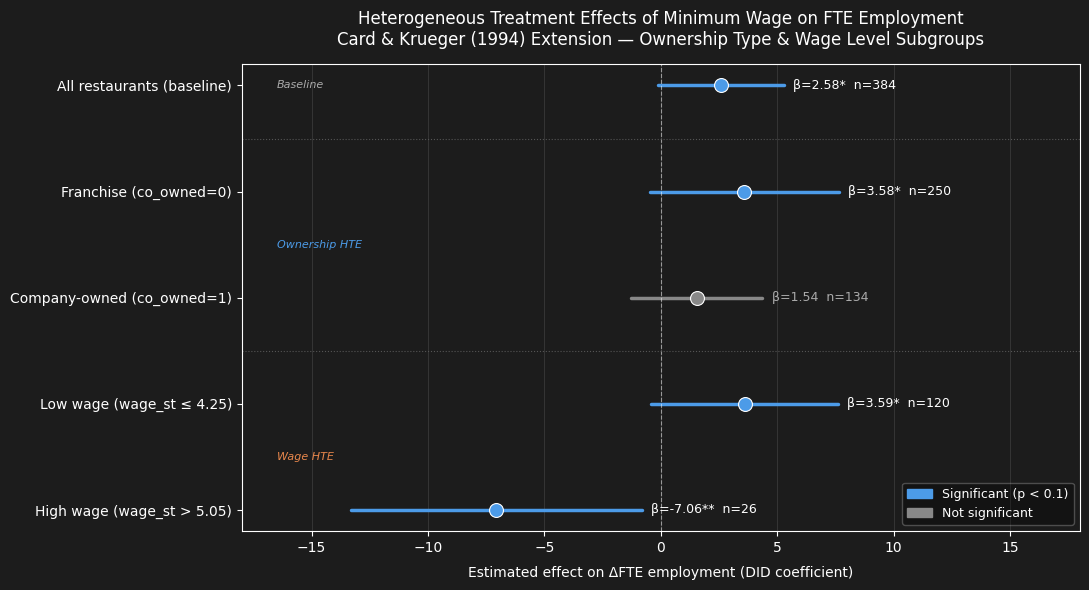

Forest plot saved as forest_plot_HTE.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11, 6))

# ── Color scheme ──────────────────────────────────────────────────────────────
# Blue = significant (p < 0.1), Gray = not significant
colors = ['#4C9BE8' if row['sig'] else '#888888' for _, row in results_df.iterrows()]

# ── Horizontal separators: baseline vs ownership vs wage groups ───────────────
# Group labels for annotation
group_labels = {
    0: 'Baseline',
    1: 'Ownership HTE',
    2: 'Ownership HTE',
    3: 'Wage HTE',
    4: 'Wage HTE',
}
group_colors = {
    'Baseline'     : '#AAAAAA',
    'Ownership HTE': '#4C9BE8',
    'Wage HTE'     : '#E8874C',
}

y_positions = list(range(len(results_df)))

# ── Draw confidence intervals and point estimates ─────────────────────────────
for i, (_, row) in enumerate(results_df.iterrows()):
    color = colors[i]
    # CI line
    ax.plot([row['ci_lo'], row['ci_hi']], [i, i],
            color=color, linewidth=2.5, zorder=2, solid_capstyle='round')
    # Point estimate
    ax.scatter(row['coef'], i,
               color=color, s=100, zorder=3, edgecolors='white', linewidths=0.8)
    # Coefficient + CI annotation on the right
    stars = '***' if row['pval']<0.01 else '**' if row['pval']<0.05 else '*' if row['pval']<0.1 else ''
    ax.text(
        row['ci_hi'] + 0.4, i,
        f"β={row['coef']:.2f}{stars}  n={row['n']}",
        va='center', ha='left', fontsize=9,
        color='white' if row['sig'] else '#AAAAAA'
    )

# ── Zero reference line ───────────────────────────────────────────────────────
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Horizontal separator between baseline and HTE groups ─────────────────────
ax.axhline(0.5, color='#555555', linewidth=0.8, linestyle=':')
ax.axhline(2.5, color='#555555', linewidth=0.8, linestyle=':')

# ── Group annotations on the left margin ─────────────────────────────────────
ax.text(-16.5, 0,   'Baseline',      va='center', ha='left', fontsize=8,
        color='#AAAAAA', style='italic')
ax.text(-16.5, 1.5, 'Ownership HTE', va='center', ha='left', fontsize=8,
        color='#4C9BE8', style='italic')
ax.text(-16.5, 3.5, 'Wage HTE',      va='center', ha='left', fontsize=8,
        color='#E8874C', style='italic')

# ── Y-axis labels ─────────────────────────────────────────────────────────────
ax.set_yticks(y_positions)
ax.set_yticklabels(results_df['label'], fontsize=10)
ax.invert_yaxis()

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.set_xlabel('Estimated effect on ΔFTE employment (DID coefficient)',
              fontsize=10, labelpad=8)
ax.set_xlim(-18, 18)

# ── Title and subtitle ────────────────────────────────────────────────────────
ax.set_title(
    'Heterogeneous Treatment Effects of Minimum Wage on FTE Employment\n'
    'Card & Krueger (1994) Extension — Ownership Type & Wage Level Subgroups',
    fontsize=12, pad=14, fontweight='normal'
)

# ── Legend ────────────────────────────────────────────────────────────────────
sig_patch   = mpatches.Patch(color='#4C9BE8', label='Significant (p < 0.1)')
insig_patch = mpatches.Patch(color='#888888', label='Not significant')
ax.legend(handles=[sig_patch, insig_patch],
          loc='lower right', fontsize=9, framealpha=0.3)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.grid(axis='x', alpha=0.15, linewidth=0.5)
ax.set_facecolor('#1C1C1C')
fig.patch.set_facecolor('#1C1C1C')

plt.tight_layout()
plt.savefig('forest_plot_HTE.png', dpi=150, bbox_inches='tight',
            facecolor='#1C1C1C')
plt.show()
print("Forest plot saved as forest_plot_HTE.png")

In [15]:
!pip install stargazer -q

from stargazer.stargazer import Stargazer
from IPython.display import HTML

# ── Stargazer regression table ────────────────────────────────────────────────
# Note: stargazer requires models fitted WITHOUT cov_type (refit with standard errors)
# We refit here only for table display purposes

m1_s = smf.ols('delta_fte ~ nj', data=df_model).fit()
m2_s = smf.ols('delta_fte ~ nj * co_owned', data=df_model).fit()
m3_s = smf.ols('delta_fte ~ nj * co_owned + delta_unemp', data=df_model).fit()
m4_s = smf.ols(
    'delta_fte ~ nj * co_owned + delta_unemp + C(chain) + wage_st',
    data=df_model
).fit()

# ── Build table ───────────────────────────────────────────────────────────────
star = Stargazer([m1_s, m2_s, m3_s, m4_s])

# Customize
star.title('Table 2: HTE Regression Results — Minimum Wage and FTE Employment')
star.custom_columns(
    ['Baseline DID', 'HTE (no BLS)', 'HTE + BLS', 'HTE + Full Controls'],
    [1, 1, 1, 1]
)
star.show_model_numbers(False)
star.covariate_order([
    'nj', 'co_owned', 'nj:co_owned',
    'delta_unemp', 'wage_st'
])
star.rename_covariates({
    'nj'          : 'New Jersey (NJ)',
    'co_owned'    : 'Company-owned',
    'nj:co_owned' : 'NJ × Company-owned (HTE)',
    'delta_unemp' : 'ΔBLS Unemployment Rate',
    'wage_st'     : 'Starting Wage ($/hr)',
})
star.add_line('Chain FE',    ['No', 'No', 'No', 'Yes'])
star.add_line('BLS Control', ['No', 'No', 'Yes', 'Yes'])
star.show_degrees_of_freedom(False)

# ── Render in notebook ────────────────────────────────────────────────────────
display(HTML(star.render_html()))

# ── Also save as HTML file ────────────────────────────────────────────────────
with open('regression_table.html', 'w') as f:
    f.write(star.render_html())
print("Table saved as regression_table.html")

Table saved as regression_table.html


## Executive Summary

This extension investigates whether the employment effects of New Jersey's 1992 minimum
wage increase — documented by Card & Krueger (1994) — varied systematically across
restaurant ownership types (franchise vs. company-owned) and initial wage levels.
Using the original C&K survey data enriched with BLS county-level unemployment rates
from FRED, we estimate heterogeneous treatment effects (HTE) via subgroup DID regressions
and an interaction term specification. The BLS data serve as a control for local
macroeconomic conditions, addressing the concern that observed differences across
ownership types may reflect geographic economic trends rather than true ownership effects.
Across all model specifications, the interaction coefficient (nj:co_owned) remains stable
at approximately −1.0 (p > 0.65), confirming that the ownership HTE is not an artifact
of regional economic differences.

Our findings both support and contextualize the original paper's conclusions. The
baseline DID estimate (β = 2.58, p < 0.1) replicates C&K's core finding that the minimum
wage increase did not reduce employment. However, this average effect conceals meaningful
heterogeneity: franchise restaurants experienced a larger and marginally significant
employment gain (β = 3.58, p < 0.1, n = 250), while company-owned stores showed a
smaller, statistically insignificant response (β = 1.54, p = 0.28, n = 134). This
pattern is consistent with the hypothesis that franchisees, as independent operators
bearing the full cost of labor directly, have stronger incentives to adjust operations
efficiently rather than reduce headcount. The wage-level subgroup analysis further reveals
that restaurants initially paying at or below the old minimum wage (β = 3.59, p < 0.1)
drove the positive employment effect, while high-wage stores — already above the new
minimum — experienced a significant employment decline (β = −7.06, p < 0.05), echoing
Ropponen's (2010) finding that C&K's positive result holds only for smaller,
lower-wage establishments. Taken together, these results suggest that the canonical
finding of non-negative minimum wage employment effects is concentrated among
franchise-operated and wage-constrained restaurants, offering a more nuanced picture
of how labor market policy propagates through heterogeneous firm structures.
